# Detector de Fraude em Documentos com Redes Neurais

Alunos:

2427812 - Jhonattan Nascimento Barbosa

2428540 - João Pedro Lucena

## 1. Objetivo

O objetivo deste projeto é desenvolver um classificador capaz de identificar possíveis fraudes em documentos financeiros a partir de atributos numéricos extraídos do texto.

Para tornar o estudo mais consistente, o conjunto de dados foi construído de forma **probabilística**, simulando um cenário mais próximo do mundo real, no qual a fraude não depende de uma única regra fixa, mas de uma combinação de fatores e ruído.


In [25]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)


## 2. Geração do dataset sintético

O dataset foi criado com variáveis maiores e com uma lógica de fraude **probabilística**.  
Isso evita um problema comum em trabalhos iniciais: criar uma classe-alvo totalmente determinística, que torna a tarefa artificialmente fácil.

### Variáveis simuladas
- `valor_total`: valor financeiro total encontrado no documento  
- `quantidade_itens`: quantidade de itens identificados  
- `desconto_percentual`: desconto aplicado no documento  
- `horario_documento`: hora da emissão do documento  
- `qtd_campos_editados`: quantidade de campos editados manualmente  
- `qtd_inconsistencias_texto`: inconsistências textuais encontradas  
- `cliente_novo`: indica se o cliente é novo ou recorrente


In [26]:
n = 1200

df = pd.DataFrame({
    "valor_total": np.random.gamma(shape=2.2, scale=1800, size=n).clip(80, 25000),
    "quantidade_itens": np.random.randint(1, 25, size=n),
    "desconto_percentual": np.random.beta(2, 5, size=n) * 60,
    "horario_documento": np.random.randint(0, 24, size=n),
    "qtd_campos_editados": np.random.poisson(lam=1.5, size=n).clip(0, 8),
    "qtd_inconsistencias_texto": np.random.poisson(lam=1.2, size=n).clip(0, 7),
    "cliente_novo": np.random.binomial(1, 0.35, size=n)
})

# Regra probabilística: múltiplos fatores aumentam ou reduzem a chance de fraude
score = (
    0.00022 * df["valor_total"]
    + 0.10 * df["desconto_percentual"]
    + 0.55 * df["qtd_campos_editados"]
    + 0.70 * df["qtd_inconsistencias_texto"]
    + 0.85 * df["cliente_novo"]
    - 0.08 * df["quantidade_itens"]
    + 0.45 * ((df["horario_documento"] <= 5) | (df["horario_documento"] >= 22)).astype(int)
    + 0.60 * ((df["valor_total"] > 8000) & (df["desconto_percentual"] > 20)).astype(int)
    + np.random.normal(0, 1.0, size=n)   # ruído
)

prob_fraude = 1 / (1 + np.exp(-(score - 4.7)))
df["fraude"] = np.random.binomial(1, prob_fraude)

df.head()


,valor_total,quantidade_itens,desconto_percentual,horario_documento,qtd_campos_editados,qtd_inconsistencias_texto,cliente_novo,fraude
0,4735.568197,9,14.454578,15,1,2,0,0
1,3031.312238,17,8.232991,15,1,1,1,0
2,2816.424301,12,24.460861,7,0,2,0,0
3,2816.460196,7,17.975238,6,6,2,0,0
4,8932.230899,10,28.169628,5,1,0,0,1


## 3. Análise exploratória dos dados

Antes do treino, é importante entender:
- distribuição das variáveis
- balanceamento da variável-alvo
- comportamento médio dos atributos entre classes

Essa etapa mostra domínio sobre os dados e fortalece a análise metodológica do trabalho.


In [27]:
print("Dimensão do dataset:", df.shape)
print("\nDistribuição da variável-alvo:")
print(df["fraude"].value_counts().sort_index())
print("\nProporção da variável-alvo:")
print(df["fraude"].value_counts(normalize=True).sort_index().round(3))


Dimensão do dataset: (1200, 8)

Distribuição da variável-alvo:
fraude
0    787
1    413
Name: count, dtype: int64

Proporção da variável-alvo:
fraude
0    0.656
1    0.344
Name: proportion, dtype: float64


In [28]:
display(df.describe().round(2))


,valor_total,quantidade_itens,desconto_percentual,horario_documento,qtd_campos_editados,qtd_inconsistencias_texto,cliente_novo,fraude
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,4033.52,12.81,16.53,11.46,1.52,1.19,0.34,0.34
std,2585.09,6.92,9.17,6.85,1.29,1.07,0.47,0.48
min,80.00,1.00,0.16,0.00,0.00,0.00,0.00,0.00
25%,2117.53,7.00,9.34,5.00,1.00,0.00,0.00,0.00
50%,3492.81,13.00,15.48,12.00,1.00,1.00,0.00,0.00
75%,5295.07,19.00,22.52,17.00,2.00,2.00,1.00,1.00
max,14678.78,24.00,46.95,23.00,8.00,6.00,1.00,1.00


In [29]:
media_por_classe = df.groupby("fraude").mean(numeric_only=True).round(2)
display(media_por_classe)


,valor_total,quantidade_itens,desconto_percentual,horario_documento,qtd_campos_editados,qtd_inconsistencias_texto,cliente_novo
fraude,,,,,,,
0,3603.14,13.65,14.76,11.42,1.33,1.00,0.28
1,4853.65,11.21,19.92,11.55,1.88,1.55,0.45


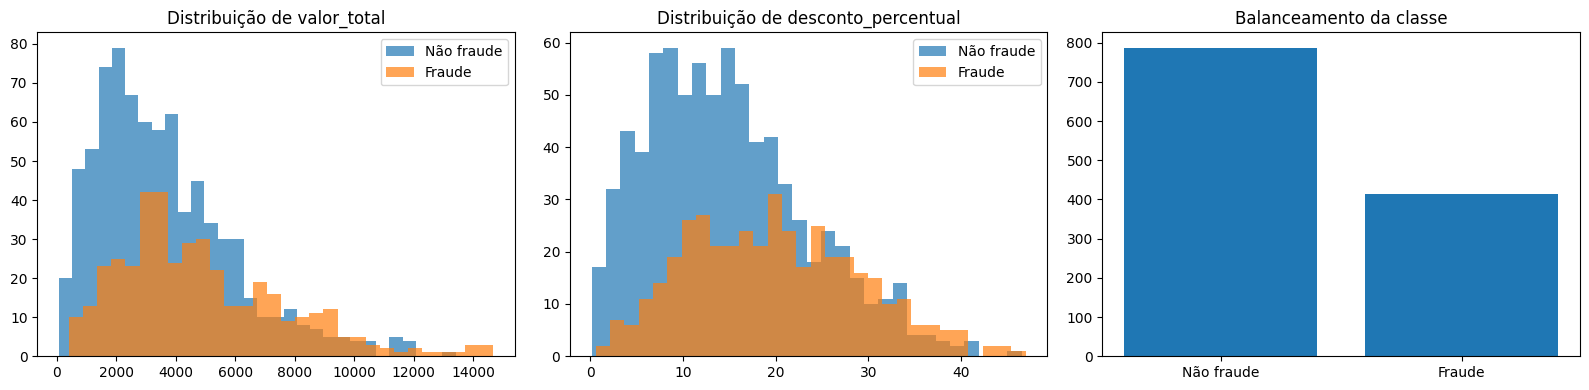

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df.loc[df["fraude"] == 0, "valor_total"], bins=30, alpha=0.7, label="Não fraude")
axes[0].hist(df.loc[df["fraude"] == 1, "valor_total"], bins=30, alpha=0.7, label="Fraude")
axes[0].set_title("Distribuição de valor_total")
axes[0].legend()

axes[1].hist(df.loc[df["fraude"] == 0, "desconto_percentual"], bins=30, alpha=0.7, label="Não fraude")
axes[1].hist(df.loc[df["fraude"] == 1, "desconto_percentual"], bins=30, alpha=0.7, label="Fraude")
axes[1].set_title("Distribuição de desconto_percentual")
axes[1].legend()

axes[2].bar(["Não fraude", "Fraude"], df["fraude"].value_counts().sort_index().values)
axes[2].set_title("Balanceamento da classe")

plt.tight_layout()
plt.show()


## 4. Separação treino/teste

1. separar `X` e `y`
2. fazer `train_test_split`
3. ajustar o `StandardScaler` **somente no treino**
4. transformar treino e teste usando o scaler já ajustado


In [31]:
features = [
    "valor_total",
    "quantidade_itens",
    "desconto_percentual",
    "horario_documento",
    "qtd_campos_editados",
    "qtd_inconsistencias_texto",
    "cliente_novo"
]

X = df[features]
y = df["fraude"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)


Treino: (960, 7)
Teste : (240, 7)


## 5. Treinamento dos modelos

Além da rede neural principal:
- **Regressão Logística** como baseline
- três arquiteturas diferentes de MLP

Isso permite discutir se a rede neural realmente trouxe ganho de desempenho ou se um modelo mais simples já resolveria bem o problema.


In [20]:
modelos = {
    "LogisticRegression (baseline)": LogisticRegression(max_iter=2000, random_state=SEED),
    "MLP (8)": MLPClassifier(hidden_layer_sizes=(8,), max_iter=1500, random_state=SEED),
    "MLP (12, 6)": MLPClassifier(hidden_layer_sizes=(12, 6), max_iter=1500, random_state=SEED),
    "MLP (32, 16)": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1500, random_state=SEED)
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    proba = modelo.predict_proba(X_test_scaled)[:, 1]

    resultados.append({
        "modelo": nome,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(resultados_df.round(4))


,modelo,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression (baseline),0.7875,0.7500,0.5783,0.6531,0.8451
1,MLP (8),0.7708,0.7059,0.5783,0.6358,0.8420
2,"MLP (12, 6)",0.7667,0.6957,0.5783,0.6316,0.8099
3,"MLP (32, 16)",0.7167,0.5974,0.5542,0.5750,0.7435


## 6. Escolha do melhor modelo

Para problemas de fraude, olhar apenas a acurácia pode ser enganoso.  
Por isso, a escolha do melhor modelo será orientada principalmente pelo **F1-score**, que combina **precision** e **recall**.


In [21]:
melhor_nome = resultados_df.loc[0, "modelo"]
melhor_modelo = modelos[melhor_nome]

pred_melhor = melhor_modelo.predict(X_test_scaled)
proba_melhor = melhor_modelo.predict_proba(X_test_scaled)[:, 1]

print("Melhor modelo:", melhor_nome)
print("\nClassification report:")
print(classification_report(y_test, pred_melhor, digits=4))


Melhor modelo: LogisticRegression (baseline)

Classification report:
              precision    recall  f1-score   support

           0     0.8011    0.8981    0.8468       157
           1     0.7500    0.5783    0.6531        83

    accuracy                         0.7875       240
   macro avg     0.7756    0.7382    0.7500       240
weighted avg     0.7835    0.7875    0.7798       240



## 7. Matriz de confusão e interpretação

A matriz de confusão ajuda a entender:
- quantas fraudes reais foram detectadas
- quantas passaram despercebidas
- quantos falsos alarmes o modelo gerou

Em cenários de fraude, isso é muito mais útil do que olhar somente uma métrica isolada.


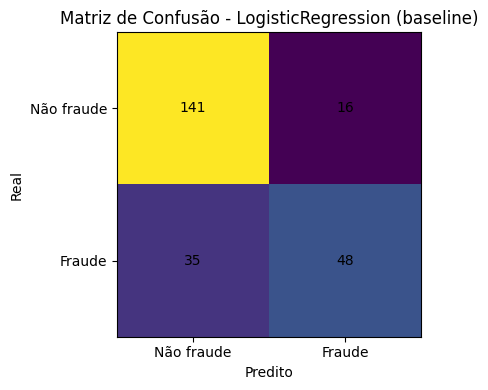

In [22]:
cm = confusion_matrix(y_test, pred_melhor)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title(f"Matriz de Confusão - {melhor_nome}")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Não fraude", "Fraude"])
ax.set_yticklabels(["Não fraude", "Fraude"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 8. Comparação visual entre os modelos


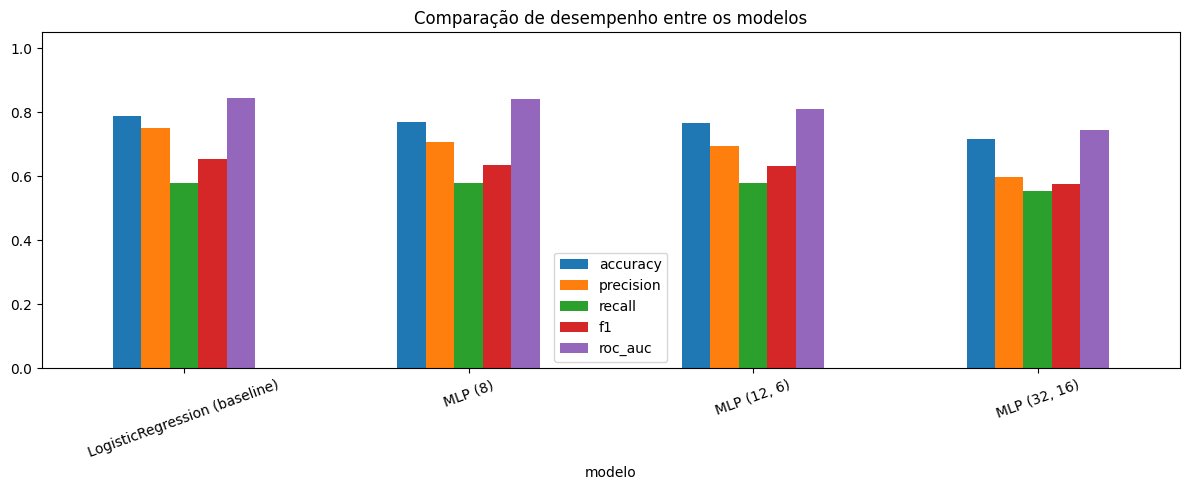

In [23]:
ax = resultados_df.set_index("modelo")[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar",
    figsize=(12, 5),
    rot=20,
    title="Comparação de desempenho entre os modelos"
)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 9. Simulação prática de análise de documento

Nesta etapa, os atributos extraídos do texto são mantidos **coerentes** com as variáveis usadas no treinamento.

Isso resolve outro problema comum: prever usando atributos que não representam exatamente as mesmas features utilizadas no modelo.


In [24]:
texto = '''
Extrato financeiro emitido às 23h.
Cliente novo.
Valores encontrados: R$ 8.950,00; R$ 1.350,00.
Documento com desconto de 28%.
Campos editados manualmente: 3.
Foram identificadas 2 inconsistências textuais.
'''

# Extração de valores monetários
valores = re.findall(r'\d{1,3}(?:\.\d{3})*,\d{2}', texto)
valores_numericos = [float(v.replace(".", "").replace(",", ".")) for v in valores]
valor_total = sum(valores_numericos)

# Extração das demais features
desconto_match = re.search(r'(\d+)%', texto)
desconto_percentual = float(desconto_match.group(1)) if desconto_match else 0.0

hora_match = re.search(r'(\d{1,2})h', texto.lower())
horario_documento = int(hora_match.group(1)) if hora_match else 12

campos_editados_match = re.search(r'campos editados manualmente:\s*(\d+)', texto.lower())
qtd_campos_editados = int(campos_editados_match.group(1)) if campos_editados_match else 0

incons_match = re.search(r'identificadas\s*(\d+)\s*inconsist', texto.lower())
qtd_inconsistencias_texto = int(incons_match.group(1)) if incons_match else 0

cliente_novo = 1 if "cliente novo" in texto.lower() else 0
quantidade_itens = len(valores_numericos)

entrada = pd.DataFrame([{
    "valor_total": valor_total,
    "quantidade_itens": quantidade_itens,
    "desconto_percentual": desconto_percentual,
    "horario_documento": horario_documento,
    "qtd_campos_editados": qtd_campos_editados,
    "qtd_inconsistencias_texto": qtd_inconsistencias_texto,
    "cliente_novo": cliente_novo
}])

entrada_scaled = scaler.transform(entrada)
pred_doc = melhor_modelo.predict(entrada_scaled)[0]
proba_doc = melhor_modelo.predict_proba(entrada_scaled)[0, 1]

display(entrada)

print(f"Classificação prevista: {'Fraude' if pred_doc == 1 else 'Não fraude'}")
print(f"Probabilidade estimada de fraude: {proba_doc:.2%}")


,valor_total,quantidade_itens,desconto_percentual,horario_documento,qtd_campos_editados,qtd_inconsistencias_texto,cliente_novo
0,10300.0,2,28.0,23,3,2,1


Classificação prevista: Fraude
Probabilidade estimada de fraude: 98.70%
